In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import plotly

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("All required libraries are working!")

Pandas: 2.3.3
NumPy: 2.3.5
Scikit-learn: 1.7.2
All required libraries are working!


In [4]:
print("RetailIQ is ready!")

RetailIQ is ready!


In [5]:
import pandas as pd

file_path = "../data/raw/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
# Basic dataset understanding

print("===== DATASET SHAPE =====")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n===== COLUMN NAMES =====")
print(df.columns.tolist())

print("\n===== FIRST 5 ROWS =====")
display(df.head())

print("\n===== DATA TYPES & NON-NULL VALUES =====")
df.info()

===== DATASET SHAPE =====
Rows: 541909
Columns: 8

===== COLUMN NAMES =====
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

===== FIRST 5 ROWS =====


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



===== DATA TYPES & NON-NULL VALUES =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
# ===== DATA QUALITY CHECK =====

print("===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== DUPLICATE ROWS =====")
print("Number of duplicate rows:", df.duplicated().sum())

print("\n===== NEGATIVE QUANTITIES =====")
print("Negative quantity rows:", (df["Quantity"] < 0).sum())

print("\n===== ZERO/NEGATIVE PRICES =====")
print("Zero or negative UnitPrice rows:", (df["UnitPrice"] <= 0).sum())

print("\n===== UNIQUE CUSTOMERS =====")
print("Unique customers:", df["CustomerID"].nunique())

print("\n===== UNIQUE PRODUCTS =====")
print("Unique products:", df["StockCode"].nunique())

print("\n===== COUNTRIES =====")
print("Number of countries:", df["Country"].nunique())

===== MISSING VALUES =====
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

===== DUPLICATE ROWS =====
Number of duplicate rows: 5268

===== NEGATIVE QUANTITIES =====
Negative quantity rows: 10624

===== ZERO/NEGATIVE PRICES =====
Zero or negative UnitPrice rows: 2517

===== UNIQUE CUSTOMERS =====
Unique customers: 4372

===== UNIQUE PRODUCTS =====
Unique products: 4070

===== COUNTRIES =====
Number of countries: 38


In [8]:
# ===== INVESTIGATE RETURNS / CANCELLATIONS =====

returns = df[df["Quantity"] < 0]

print("Total return/cancellation records:", len(returns))

print("\nSample return records:")
display(returns.head(10))

print("\nInvoice numbers for returns:")
print(returns["InvoiceNo"].head(20).tolist())

print("\nMost common return quantities:")
print(returns["Quantity"].value_counts().head(10))

Total return/cancellation records: 10624

Sample return records:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom



Invoice numbers for returns:
['C536379', 'C536383', 'C536391', 'C536391', 'C536391', 'C536391', 'C536391', 'C536391', 'C536391', 'C536506', 'C536543', 'C536543', 'C536548', 'C536548', 'C536548', 'C536548', 'C536548', 'C536548', 'C536548', 'C536548']

Most common return quantities:
Quantity
-1     4184
-2     1395
-3      620
-12     564
-6      518
-4      502
-24     261
-5      235
-10     197
-8      169
Name: count, dtype: int64


In [9]:
# ===== CREATE CLEAN SALES DATASET =====

# Keep the original raw dataset unchanged
clean_df = df.copy()

# 1. Remove duplicate transactions
clean_df = clean_df.drop_duplicates()

# 2. Remove transactions without CustomerID
clean_df = clean_df.dropna(subset=["CustomerID"])

# 3. Remove invalid prices
clean_df = clean_df[clean_df["UnitPrice"] > 0]

# 4. Keep positive quantities for sales analysis
clean_df = clean_df[clean_df["Quantity"] > 0]

print("===== CLEANING RESULTS =====")
print("Original rows:", len(df))
print("Clean rows:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))

print("\nRemaining missing values:")
print(clean_df.isnull().sum())

print("\nRemaining negative quantities:", (clean_df["Quantity"] < 0).sum())
print("Remaining invalid prices:", (clean_df["UnitPrice"] <= 0).sum())

===== CLEANING RESULTS =====
Original rows: 541909
Clean rows: 392692
Rows removed: 149217

Remaining missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Remaining negative quantities: 0
Remaining invalid prices: 0


In [10]:
# ===== CALCULATE REVENUE =====

clean_df["Revenue"] = clean_df["Quantity"] * clean_df["UnitPrice"]

print("Revenue column created successfully!")

print("\nSample transactions:")
display(clean_df[[
    "InvoiceNo",
    "StockCode",
    "Quantity",
    "UnitPrice",
    "Revenue",
    "CustomerID",
    "Country"
]].head())

Revenue column created successfully!

Sample transactions:


,InvoiceNo,StockCode,Quantity,UnitPrice,Revenue,CustomerID,Country
0,536365,85123A,6,2.55,15.30,17850.0,United Kingdom
1,536365,71053,6,3.39,20.34,17850.0,United Kingdom
2,536365,84406B,8,2.75,22.00,17850.0,United Kingdom
3,536365,84029G,6,3.39,20.34,17850.0,United Kingdom
4,536365,84029E,6,3.39,20.34,17850.0,United Kingdom


In [11]:
# ===== RETAILIQ SALES KPIs =====

total_revenue = clean_df["Revenue"].sum()
total_quantity = clean_df["Quantity"].sum()
total_orders = clean_df["InvoiceNo"].nunique()
total_customers = clean_df["CustomerID"].nunique()
total_products = clean_df["StockCode"].nunique()

average_order_value = total_revenue / total_orders

print("===== RETAILIQ SALES KPIs =====")
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Products: {total_products:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

===== RETAILIQ SALES KPIs =====
Total Revenue: £8,887,208.89
Total Quantity Sold: 5,152,002
Total Orders: 18,532
Total Customers: 4,338
Total Products: 3,665
Average Order Value: £479.56


In [12]:
# ===== DATE PREPARATION =====

clean_df["InvoiceDate"] = pd.to_datetime(clean_df["InvoiceDate"])

print("InvoiceDate data type:", clean_df["InvoiceDate"].dtype)

print("\nDate range:")
print("Start:", clean_df["InvoiceDate"].min())
print("End:", clean_df["InvoiceDate"].max())

InvoiceDate data type: datetime64[ns]

Date range:
Start: 2010-12-01 08:26:00
End: 2011-12-09 12:50:00


In [13]:
# ===== MONTHLY SALES =====

monthly_sales = (
    clean_df
    .set_index("InvoiceDate")
    .resample("ME")["Revenue"]
    .sum()
    .reset_index()
)

monthly_sales.columns = ["Month", "Revenue"]

display(monthly_sales)

,Month,Revenue
0,2010-12-31,570422.730
1,2011-01-31,568101.310
2,2011-02-28,446084.920
3,2011-03-31,594081.760
4,2011-04-30,468374.331
5,2011-05-31,677355.150
6,2011-06-30,660046.050
7,2011-07-31,598962.901
8,2011-08-31,644051.040
9,2011-09-30,950690.202


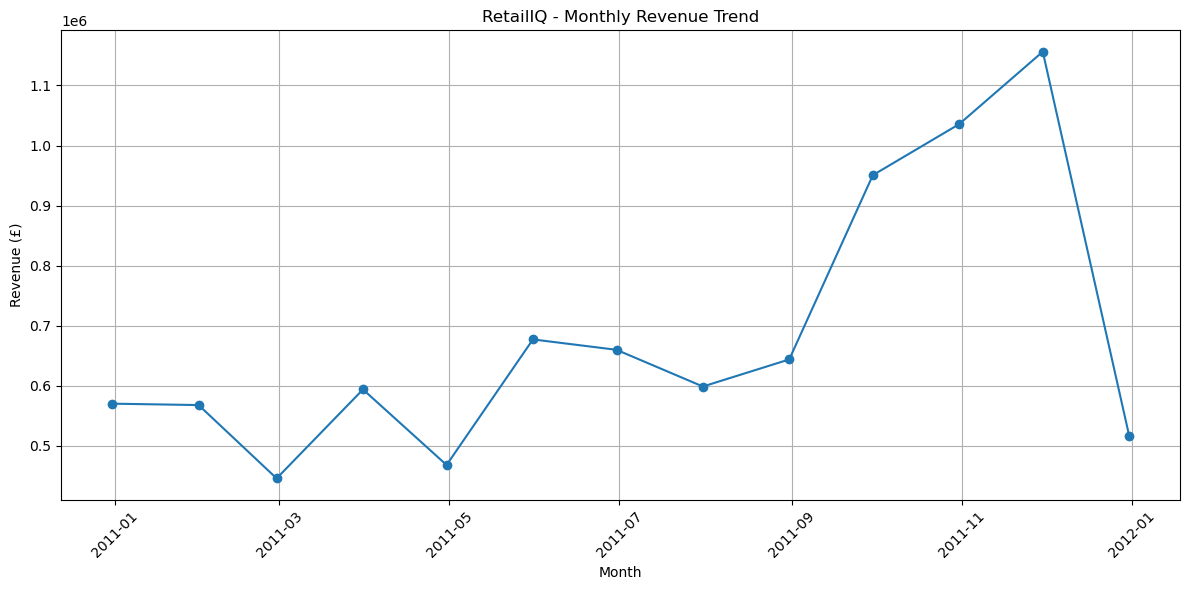

In [14]:
# ===== MONTHLY REVENUE TREND =====

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("RetailIQ - Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [17]:
### Observation The monthly revenue trend shows fluctuations in sales throughout the period. Revenue increased significantly toward the end of 2011, reaching its highest level in December 2011. This indicates stronger sales activity during the later months and provides a useful basis for further sales trend and forecasting analysis.

In [18]:
# ===== TOP 10 PRODUCTS BY REVENUE =====

top_products = (
    clean_df
    .groupby(["StockCode", "Description"])["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

display(top_products)

,StockCode,Description,Revenue
0,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,22423,REGENCY CAKESTAND 3 TIER,142264.75
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,100392.10
3,85099B,JUMBO BAG RED RETROSPOT,85040.54
4,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POST,POSTAGE,77803.96
6,47566,PARTY BUNTING,68785.23
7,84879,ASSORTED COLOUR BIRD ORNAMENT,56413.03
8,M,Manual,53419.93
9,23084,RABBIT NIGHT LIGHT,51251.24


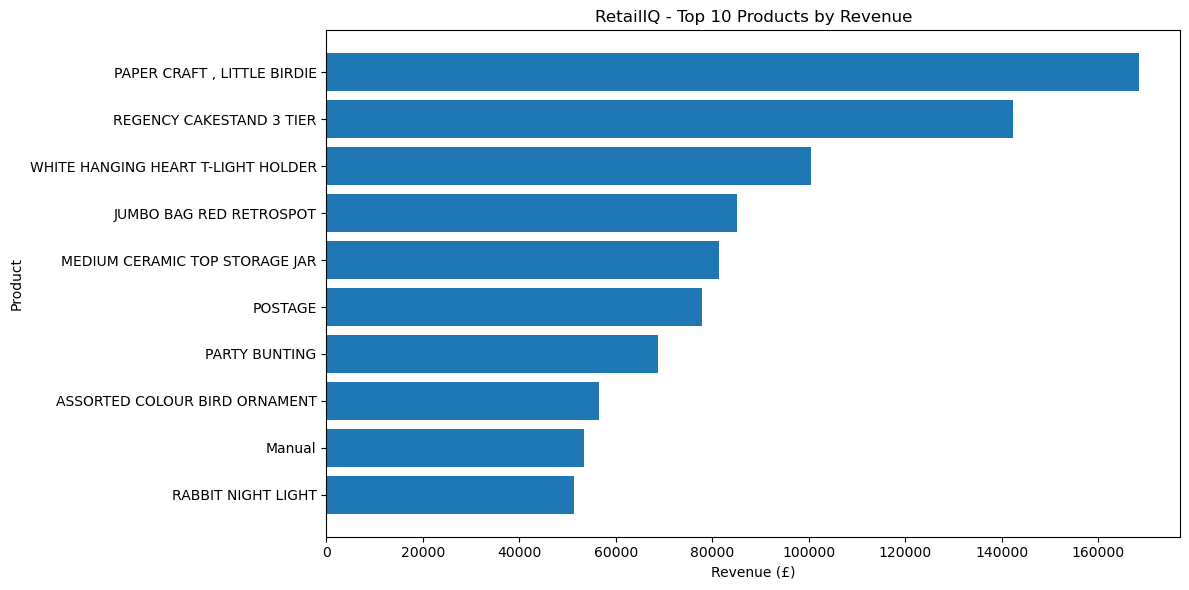

In [19]:
# ===== TOP 10 PRODUCTS REVENUE CHART =====

plt.figure(figsize=(12, 6))

plt.barh(
    top_products["Description"].astype(str),
    top_products["Revenue"]
)

plt.title("RetailIQ - Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
# ===== SAVE CLEAN DATA =====

clean_df.to_csv(
    "../data/processed/clean_sales_data.csv",
    index=False
)

print("Clean sales dataset saved successfully!")

Clean sales dataset saved successfully!
